# 01 — NoisyMNIST dataset and experimental protocol

## 1. Goal

This notebook implements and validates **Phase 1** of a scientific reproduction of the
Sutton & Javed (2026) NoisyMNIST experiment described in *Learning from experience
instead of curated datasets*.

Scope is intentionally limited to reproducibility infrastructure, leakage-free MNIST
partitions, the batch-size-one online experience stream, deterministic finite evaluation
streams, statistical checks, and visual diagnostics. It does **not** construct or train a
model, implement SGD, or infer any missing NetworkIDBD equations.


## 2. Paper specification

At each online time step:

- create a 64 × 64 canvas;
- reserve rows 18:46 and columns 18:46 as the centered 28 × 28 useful region;
- independently activate each of the 3,312 outer pixels with Bernoulli probability 0.01;
- with probability 0.10, place one unaugmented MNIST digit in the useful region;
- use clean target +1 for an odd digit, −1 for an even digit (including zero), and 0
  when no digit is present;
- add independent Gaussian target noise with mean 0 and variance 5.

Thus, noisy_target = clean_target + gaussian_noise. The center is never exposed to
Bernoulli background noise: it contains either the MNIST tensor or exact zeros.


## 3. Environment

The versions below are captured in the executed artifact. Stream randomness is generated
on CPU by a dedicated generator even if the configured output device is CUDA, so the
ordered experiences do not depend on unrelated global random draws.


In [1]:
from __future__ import annotations

import math
import platform
import random
import sys
import time
from dataclasses import asdict, dataclass
from pathlib import Path
from types import MappingProxyType
from typing import Any, Iterator, Optional, Sequence, TypedDict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchvision
from IPython.display import display
from matplotlib.patches import Rectangle
from torch import Tensor
from torchvision import transforms
from torchvision.datasets import MNIST

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.grid": False,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)

print(f"Python version:      {platform.python_version()}")
print(f"PyTorch version:     {torch.__version__}")
print(f"torchvision version: {torchvision.__version__}")
print(f"CUDA available:      {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name:            {torch.cuda.get_device_name(0)}")
else:
    print("GPU name:            n/a (CPU execution)")


Python version:      3.12.14
PyTorch version:     2.13.0+cpu
torchvision version: 0.28.0+cpu
CUDA available:      False
GPU name:            n/a (CPU execution)


## 4. Configuration

### PAPER_DEFINED

These are the values explicitly specified by Sutton & Javed: canvas and digit geometry,
digit probability, outer-feature Bernoulli probability, and target-noise variance. The
standard deviation is derived as the square root of the paper-defined variance.

### REPRODUCTION_PROTOCOL

These are our scientific protocol additions: the 55,000/5,000 deterministic stratified
split, random seeds, diagnostic sample count, dtype/device policy, and an explicit
normalization flag. They are **not** attributed to the short paper.


In [2]:
PAPER_DEFINED = MappingProxyType(
    {
        "canvas_size": 64,
        "digit_size": 28,
        "center_start": 18,
        "center_stop": 46,
        "digit_probability": 0.10,
        "background_probability": 0.01,
        "odd_clean_target": 1.0,
        "even_clean_target": -1.0,
        "absent_clean_target": 0.0,
        "target_noise_mean": 0.0,
        "target_noise_variance": 5.0,
        "target_noise_std": math.sqrt(5.0),
    }
)

REPRODUCTION_PROTOCOL = MappingProxyType(
    {
        "train_size": 55_000,
        "validation_size": 5_000,
        "split_seed": 20_260_201,
        "train_stream_seed": 314_159,
        "validation_stream_seed": 271_828,
        "test_stream_seed": 161_803,
        "statistics_stream_seed": 424_242,
        "diagnostic_stream_seed": 616_109,
        "visualization_stream_seed": 515_151,
        "statistics_num_steps": 50_000,
        "dtype": torch.float32,
        "device": "cuda" if torch.cuda.is_available() else "cpu",
        "normalize_mnist": False,
    }
)


@dataclass(frozen=True)
class ExperimentConfig:
    """Complete configuration for Phase 1 of the NoisyMNIST reproduction."""

    # PAPER_DEFINED
    canvas_size: int = PAPER_DEFINED["canvas_size"]
    digit_size: int = PAPER_DEFINED["digit_size"]
    center_start: int = PAPER_DEFINED["center_start"]
    center_stop: int = PAPER_DEFINED["center_stop"]
    digit_probability: float = PAPER_DEFINED["digit_probability"]
    background_probability: float = PAPER_DEFINED["background_probability"]
    odd_clean_target: float = PAPER_DEFINED["odd_clean_target"]
    even_clean_target: float = PAPER_DEFINED["even_clean_target"]
    absent_clean_target: float = PAPER_DEFINED["absent_clean_target"]
    target_noise_mean: float = PAPER_DEFINED["target_noise_mean"]
    target_noise_variance: float = PAPER_DEFINED["target_noise_variance"]
    target_noise_std: float = PAPER_DEFINED["target_noise_std"]

    # REPRODUCTION_PROTOCOL
    train_size: int = REPRODUCTION_PROTOCOL["train_size"]
    validation_size: int = REPRODUCTION_PROTOCOL["validation_size"]
    split_seed: int = REPRODUCTION_PROTOCOL["split_seed"]
    train_stream_seed: int = REPRODUCTION_PROTOCOL["train_stream_seed"]
    validation_stream_seed: int = REPRODUCTION_PROTOCOL["validation_stream_seed"]
    test_stream_seed: int = REPRODUCTION_PROTOCOL["test_stream_seed"]
    statistics_stream_seed: int = REPRODUCTION_PROTOCOL["statistics_stream_seed"]
    diagnostic_stream_seed: int = REPRODUCTION_PROTOCOL["diagnostic_stream_seed"]
    visualization_stream_seed: int = REPRODUCTION_PROTOCOL["visualization_stream_seed"]
    statistics_num_steps: int = REPRODUCTION_PROTOCOL["statistics_num_steps"]
    dtype: torch.dtype = REPRODUCTION_PROTOCOL["dtype"]
    device: str = REPRODUCTION_PROTOCOL["device"]
    normalize_mnist: bool = REPRODUCTION_PROTOCOL["normalize_mnist"]

    def __post_init__(self) -> None:
        if self.canvas_size != 64 or self.digit_size != 28:
            raise ValueError("This faithful notebook requires 64x64 canvases and 28x28 digits.")
        if (self.canvas_size - self.digit_size) % 2 != 0:
            raise ValueError("The digit must have an integral centered offset.")
        expected_center_start = (self.canvas_size - self.digit_size) // 2
        if self.center_start != expected_center_start:
            raise ValueError("center_start must be the exact centered offset 18.")
        if self.center_stop != self.center_start + self.digit_size:
            raise ValueError("center_stop must be 46 for the required 28x28 center.")
        if not (0.0 <= self.digit_probability <= 1.0):
            raise ValueError("digit_probability must be in [0, 1].")
        if not (0.0 <= self.background_probability <= 1.0):
            raise ValueError("background_probability must be in [0, 1].")
        if not math.isclose(
            self.target_noise_std**2,
            self.target_noise_variance,
            rel_tol=0.0,
            abs_tol=1e-12,
        ):
            raise ValueError("target_noise_std must equal sqrt(target_noise_variance).")
        if self.dtype is not torch.float32:
            raise TypeError("Phase 1 stream outputs are required to be torch.float32.")
        if self.normalize_mnist:
            raise ValueError(
                "Mean/std normalization is disabled in the faithful protocol; "
                "implement and label it explicitly only as a later ablation."
            )
        if self.statistics_num_steps < 50_000:
            raise ValueError("The requested statistical audit requires at least 50,000 steps.")

    @property
    def num_pixels(self) -> int:
        return self.canvas_size**2

    @property
    def num_outer_pixels(self) -> int:
        return self.num_pixels - self.digit_size**2


config = ExperimentConfig()

assert config.center_start == 18
assert config.center_stop == 46
assert config.num_pixels == 4_096
assert config.num_outer_pixels == 3_312
assert config.target_noise_std == math.sqrt(5.0)

config_display = asdict(config)
config_display["dtype"] = str(config.dtype)
display(pd.Series(config_display, name="value").to_frame())


,value
canvas_size,64
digit_size,28
center_start,18
center_stop,46
digit_probability,0.1
background_probability,0.01
odd_clean_target,1.0
even_clean_target,-1.0
absent_clean_target,0.0
target_noise_mean,0.0


## 5. Reproducibility

The utility below seeds Python, NumPy, torch CPU, and every visible CUDA device. PyTorch
deterministic algorithms and deterministic cuDNN behavior are requested where practical.
Absolute bitwise identity can still depend on library versions, hardware, drivers, and
whether a particular CUDA operation has a deterministic implementation. The stream itself
owns a CPU torch.Generator; it never uses global randomness during sample generation.


In [3]:
def seed_everything(seed: int) -> None:
    """Seed global libraries used outside the independently seeded online streams."""

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.use_deterministic_algorithms(True, warn_only=True)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


seed_everything(config.split_seed)
print(f"Global reproducibility seed initialized to {config.split_seed}.")


Global reproducibility seed initialized to 20260201.


## 6. MNIST partitions

torchvision MNIST is loaded with only ToTensor, which naturally maps pixels to float32
values in [0, 1]. There is no augmentation and no dataset mean/std normalization. Preserving
[0, 1] pixels is an explicit reproduction assumption because the short note does not specify
mean/std normalization.

The official 60,000-image training partition supplies train and validation only. A local
NumPy generator performs a deterministic stratified split with proportional per-class
allocation and largest-remainder rounding. The official 10,000-image test partition is
loaded separately with train=False and is reserved for final testing.


In [4]:
DATA_ROOT = Path("data")
mnist_transform = transforms.ToTensor()

official_train_dataset = MNIST(
    root=DATA_ROOT,
    train=True,
    download=True,
    transform=mnist_transform,
)
official_test_dataset = MNIST(
    root=DATA_ROOT,
    train=False,
    download=True,
    transform=mnist_transform,
)

assert official_train_dataset.train is True
assert official_test_dataset.train is False
assert len(official_train_dataset) == 60_000
assert len(official_test_dataset) == 10_000

probe_digit, probe_label = official_train_dataset[0]
assert probe_digit.shape == (1, 28, 28)
assert probe_digit.dtype == torch.float32
assert 0.0 <= float(probe_digit.min()) <= float(probe_digit.max()) <= 1.0
assert isinstance(int(probe_label), int)

print(f"MNIST data root: {DATA_ROOT.resolve()}")
print("Transform: ToTensor only (no normalization, augmentation, or pixel alteration).")


MNIST data root: /home/joka/Desktop/Continual/data
Transform: ToTensor only (no normalization, augmentation, or pixel alteration).


In [5]:
def stratified_split_indices(
    labels: Sequence[int] | np.ndarray | Tensor,
    validation_size: int,
    seed: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Return deterministic train/validation indices with proportional class allocation."""

    labels_array = np.asarray(labels, dtype=np.int64)
    if labels_array.ndim != 1:
        raise ValueError("labels must be one-dimensional.")
    if not 0 < validation_size < len(labels_array):
        raise ValueError("validation_size must be between zero and dataset size.")

    classes, counts = np.unique(labels_array, return_counts=True)
    exact_allocations = counts * (validation_size / len(labels_array))
    allocations = np.floor(exact_allocations).astype(np.int64)

    remainder = validation_size - int(allocations.sum())
    fractional_parts = exact_allocations - allocations
    largest_remainders = np.argsort(-fractional_parts, kind="stable")[:remainder]
    allocations[largest_remainders] += 1

    rng = np.random.default_rng(seed)
    train_parts: list[np.ndarray] = []
    validation_parts: list[np.ndarray] = []
    for digit_class, class_validation_size in zip(classes, allocations, strict=True):
        class_indices = np.flatnonzero(labels_array == digit_class)
        class_indices = rng.permutation(class_indices)
        validation_parts.append(class_indices[:class_validation_size])
        train_parts.append(class_indices[class_validation_size:])

    train_indices = np.concatenate(train_parts).astype(np.int64, copy=False)
    validation_indices = np.concatenate(validation_parts).astype(np.int64, copy=False)
    rng.shuffle(train_indices)
    rng.shuffle(validation_indices)

    if len(train_indices) + len(validation_indices) != len(labels_array):
        raise AssertionError("The split does not cover the official training partition.")
    return train_indices, validation_indices


official_train_labels = official_train_dataset.targets.cpu().numpy()
official_test_labels = official_test_dataset.targets.cpu().numpy()

train_indices, validation_indices = stratified_split_indices(
    labels=official_train_labels,
    validation_size=config.validation_size,
    seed=config.split_seed,
)
repeated_train_indices, repeated_validation_indices = stratified_split_indices(
    labels=official_train_labels,
    validation_size=config.validation_size,
    seed=config.split_seed,
)

assert len(train_indices) == config.train_size == 55_000
assert len(validation_indices) == config.validation_size == 5_000
assert np.array_equal(train_indices, repeated_train_indices)
assert np.array_equal(validation_indices, repeated_validation_indices)


In [6]:
def counts_and_fractions(labels: np.ndarray, indices: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Compute ten-class counts and fractions for selected original indices."""

    counts = np.bincount(labels[indices], minlength=10)
    return counts, counts / counts.sum()


train_counts, train_fractions = counts_and_fractions(official_train_labels, train_indices)
validation_counts, validation_fractions = counts_and_fractions(
    official_train_labels, validation_indices
)
test_counts = np.bincount(official_test_labels, minlength=10)
test_fractions = test_counts / test_counts.sum()

class_distribution = pd.DataFrame(
    {
        ("training", "count"): train_counts,
        ("training", "fraction"): train_fractions,
        ("validation", "count"): validation_counts,
        ("validation", "fraction"): validation_fractions,
        ("official_test", "count"): test_counts,
        ("official_test", "fraction"): test_fractions,
    },
    index=pd.Index(range(10), name="digit"),
)
class_distribution.columns = pd.MultiIndex.from_tuples(class_distribution.columns)
display(class_distribution)

approximately_balanced = bool(
    np.all((train_fractions > 0.08) & (train_fractions < 0.12))
    and np.all((validation_fractions > 0.08) & (validation_fractions < 0.12))
    and np.all((test_fractions > 0.08) & (test_fractions < 0.12))
)
source_fractions = np.bincount(official_train_labels, minlength=10) / 60_000
stratification_error = float(np.max(np.abs(validation_fractions - source_fractions)))

assert approximately_balanced
assert stratification_error < 5e-4
print(f"Maximum validation-vs-source class-fraction difference: {stratification_error:.6f}")
print("All partition class fractions lie between 0.08 and 0.12.")


training           validation          official_test         
         count  fraction      count fraction         count fraction
digit                                                              
0         5429  0.098709        494   0.0988           980   0.0980
1         6180  0.112364        562   0.1124          1135   0.1135
2         5462  0.099309        496   0.0992          1032   0.1032
3         5620  0.102182        511   0.1022          1010   0.1010
4         5355  0.097364        487   0.0974           982   0.0982
5         4969  0.090345        452   0.0904           892   0.0892
6         5425  0.098636        493   0.0986           958   0.0958
7         5743  0.104418        522   0.1044          1028   0.1028
8         5364  0.097527        487   0.0974           974   0.0974
9         5453  0.099145        496   0.0992          1009   0.1009

Maximum validation-vs-source class-fraction difference: 0.000117
All partition class fractions lie between 0.08 and 0.12.


## 7. NoisyMNIST stream implementation

NoisyMNISTStream is an indefinite online iterator, not a shuffled mini-batch DataLoader.
Calling next(stream) requests exactly one experience.

Conditional on a digit being present, an image is sampled uniformly **with replacement**
from the assigned pool. This supports an indefinite stream; the short paper does not specify
its exact digit-sampling scheme, so replacement is documented as our reproduction-protocol
decision. Original official-partition indices are retained in every present-digit experience.


In [7]:
class Experience(TypedDict):
    """One online NoisyMNIST experience."""

    x: Tensor
    x_flat: Tensor
    noisy_target: Tensor
    clean_target: Tensor
    gaussian_noise: Tensor
    digit_present: bool
    digit_label: Optional[int]
    mnist_index: Optional[int]
    source_partition: str
    stream_step: int


class MNISTPool:
    """A named, index-preserving view into one official MNIST partition."""

    def __init__(
        self,
        dataset: MNIST,
        indices: Sequence[int],
        name: str,
        source_partition: str,
    ) -> None:
        self.dataset = dataset
        self.indices = tuple(int(index) for index in indices)
        self.index_set = frozenset(self.indices)
        self.name = name
        self.source_partition = source_partition

        if not self.indices:
            raise ValueError(f"{name} cannot be empty.")
        if len(self.index_set) != len(self.indices):
            raise ValueError(f"{name} contains duplicate original indices.")
        if min(self.indices) < 0 or max(self.indices) >= len(dataset):
            raise IndexError(f"{name} contains an out-of-range original index.")

    def __len__(self) -> int:
        return len(self.indices)

    def get(self, pool_position: int) -> tuple[Tensor, int, int]:
        """Get tensor, label, and original official-partition index."""

        if not 0 <= pool_position < len(self):
            raise IndexError("pool_position is out of range.")
        original_index = self.indices[pool_position]
        image, label = self.dataset[original_index]
        if image.shape != (1, 28, 28) or image.dtype != torch.float32:
            raise AssertionError("MNIST transform must yield float32 [1, 28, 28] tensors.")
        return image, int(label), original_index


In [8]:
class NoisyMNISTStream(Iterator[Experience]):
    """Indefinite, batch-size-one NoisyMNIST experience stream with owned RNG state."""

    def __init__(
        self,
        pool: MNISTPool,
        config: ExperimentConfig,
        seed: int,
    ) -> None:
        if len(pool) == 0:
            raise ValueError("The digit pool must not be empty.")

        self.pool = pool
        self.config = config
        self._constructor_seed = int(seed)
        self._generator = torch.Generator(device="cpu")
        self._device = torch.device(config.device)
        if self._device.type == "cuda" and not torch.cuda.is_available():
            raise RuntimeError("CUDA was configured but is not available.")
        self.reset()

    @property
    def seed(self) -> int:
        """Seed used by the most recent reset."""

        return self._active_seed

    @property
    def stream_step(self) -> int:
        """Zero-based index of the next experience."""

        return self._stream_step

    def reset(self, seed: Optional[int] = None) -> None:
        """Reset to step zero.

        reset() restores the constructor seed. reset(seed=s) uses s for that reset
        without changing what a later argument-free reset restores.
        """

        active_seed = self._constructor_seed if seed is None else int(seed)
        self._generator.manual_seed(active_seed)
        self._active_seed = active_seed
        self._stream_step = 0

    def __iter__(self) -> "NoisyMNISTStream":
        return self

    def __next__(self) -> Experience:
        cfg = self.config
        center = slice(cfg.center_start, cfg.center_stop)
        step = self._stream_step

        # Every stochastic draw below uses this stream's private CPU generator.
        digit_present = bool(
            torch.rand((), generator=self._generator).item() < cfg.digit_probability
        )
        canvas_cpu = (
            torch.rand(
                (1, cfg.canvas_size, cfg.canvas_size),
                generator=self._generator,
            )
            < cfg.background_probability
        ).to(dtype=cfg.dtype)

        # Bernoulli draws in the center are discarded before any optional digit insertion.
        canvas_cpu[:, center, center] = 0.0

        digit_label: Optional[int] = None
        mnist_index: Optional[int] = None
        clean_value = cfg.absent_clean_target
        if digit_present:
            pool_position = int(
                torch.randint(
                    low=0,
                    high=len(self.pool),
                    size=(1,),
                    generator=self._generator,
                ).item()
            )
            digit_image, digit_label, mnist_index = self.pool.get(pool_position)
            canvas_cpu[:, center, center] = digit_image
            clean_value = (
                cfg.odd_clean_target
                if digit_label % 2 == 1
                else cfg.even_clean_target
            )

        clean_target_cpu = torch.tensor(clean_value, dtype=cfg.dtype)
        gaussian_noise_cpu = (
            torch.randn((), generator=self._generator, dtype=cfg.dtype)
            * cfg.target_noise_std
            + cfg.target_noise_mean
        )
        noisy_target_cpu = clean_target_cpu + gaussian_noise_cpu

        x = canvas_cpu.to(device=self._device)
        clean_target = clean_target_cpu.to(device=self._device)
        gaussian_noise = gaussian_noise_cpu.to(device=self._device)
        noisy_target = noisy_target_cpu.to(device=self._device)

        self._stream_step += 1
        return Experience(
            x=x,
            x_flat=x.reshape(cfg.num_pixels),
            noisy_target=noisy_target,
            clean_target=clean_target,
            gaussian_noise=gaussian_noise,
            digit_present=digit_present,
            digit_label=digit_label,
            mnist_index=mnist_index,
            source_partition=self.pool.source_partition,
            stream_step=step,
        )


In [9]:
training_pool = MNISTPool(
    official_train_dataset,
    train_indices,
    name="training",
    source_partition="official_train",
)
validation_pool = MNISTPool(
    official_train_dataset,
    validation_indices,
    name="validation",
    source_partition="official_train",
)
test_pool = MNISTPool(
    official_test_dataset,
    np.arange(len(official_test_dataset)),
    name="test",
    source_partition="official_test",
)

# Canonical streams are constructed but deliberately not advanced by diagnostics.
training_stream = NoisyMNISTStream(training_pool, config, config.train_stream_seed)
validation_stream = NoisyMNISTStream(
    validation_pool, config, config.validation_stream_seed
)
test_stream = NoisyMNISTStream(test_pool, config, config.test_stream_seed)

assert len({training_stream.seed, validation_stream.seed, test_stream.seed}) == 3
assert training_stream.stream_step == validation_stream.stream_step == test_stream.stream_step == 0
print("Created independent online train, validation, and test streams at step zero.")


Created independent online train, validation, and test streams at step zero.


## 8. Leakage checks

- **Training stream:** digits only from the 55,000-image training pool.
- **Validation stream:** digits only from the disjoint 5,000-image validation pool and a
  different RNG seed.
- **Test stream:** digits only from torchvision's independent official test partition and
  a third RNG seed.

Validation and test experiences must never update training weights. Validation is reserved
for later hyperparameter selection; the official test stream is reserved for final testing
and must not be inspected for hyperparameter selection. Integer indices in official-train
and official-test are separate namespaces, so leakage is established from partition
provenance rather than by comparing those integer values.


In [10]:
train_index_set = set(train_indices.tolist())
validation_index_set = set(validation_indices.tolist())
train_validation_intersection = train_index_set.intersection(validation_index_set)
train_validation_union = train_index_set.union(validation_index_set)

partitions_isolated = bool(
    len(training_pool) == 55_000
    and len(validation_pool) == 5_000
    and len(test_pool) == 10_000
    and not train_validation_intersection
    and train_validation_union == set(range(60_000))
    and training_pool.dataset is official_train_dataset
    and validation_pool.dataset is official_train_dataset
    and test_pool.dataset is official_test_dataset
    and official_train_dataset.train is True
    and official_test_dataset.train is False
    and approximately_balanced
)

assert len(train_index_set) == 55_000
assert len(validation_index_set) == 5_000
assert train_validation_intersection == set()
assert train_validation_union == set(range(60_000))
assert official_train_dataset is not official_test_dataset
assert partitions_isolated

partition_sizes = pd.DataFrame(
    {
        "pool": ["training", "validation", "test"],
        "size": [len(training_pool), len(validation_pool), len(test_pool)],
        "source_partition": [
            training_pool.source_partition,
            validation_pool.source_partition,
            test_pool.source_partition,
        ],
        "stream_seed": [
            training_stream.seed,
            validation_stream.seed,
            test_stream.seed,
        ],
    }
)
display(partition_sizes)
print("Train/validation original-index intersection:", train_validation_intersection)
print("Official test partition loaded independently with train=False.")


,pool,size,source_partition,stream_seed
0,training,55000,official_train,314159
1,validation,5000,official_train,271828
2,test,10000,official_test,161803


Train/validation original-index intersection: set()
Official test partition loaded independently with train=False.


## 9. Statistical validation

Diagnostics use a fresh training-pool stream with a dedicated protocol seed. They do not
advance the canonical training stream and do not sample the test stream. The audit processes
50,000 sequential experiences while retaining only scalar diagnostics, not image tensors.

Statistical acceptance bands are fixed at five standard errors under the defining
Bernoulli/Gaussian models. These are stochastic tolerance tests, not exact-equality tests.
Structural and semantic invariants are checked exactly on every diagnostic experience.


In [11]:
center_slice = slice(config.center_start, config.center_stop)
center_mask = torch.zeros(
    (config.canvas_size, config.canvas_size), dtype=torch.bool
)
center_mask[center_slice, center_slice] = True
outer_mask = ~center_mask

assert center_mask.shape == (64, 64)
assert int(center_mask.sum()) == 28 * 28 == 784
assert int(outer_mask.sum()) == 3_312
assert center_mask[18:46, 18:46].all()
assert not center_mask[:18].any()
assert not center_mask[46:].any()

shape_probe_stream = NoisyMNISTStream(
    training_pool, config, config.diagnostic_stream_seed + 1
)
shape_probe = next(shape_probe_stream)
assert shape_probe["x"].shape == (1, 64, 64)
assert shape_probe["x_flat"].shape == (4_096,)
assert shape_probe["x"].dtype == torch.float32
assert shape_probe["x_flat"].dtype == torch.float32
assert torch.equal(shape_probe["x_flat"], shape_probe["x"].reshape(-1))
for scalar_key in ("noisy_target", "clean_target", "gaussian_noise"):
    assert shape_probe[scalar_key].shape == ()
    assert shape_probe[scalar_key].dtype == torch.float32

print("Shape, dtype, center-offset, and 3,312-pixel outer-mask checks passed.")


Shape, dtype, center-offset, and 3,312-pixel outer-mask checks passed.


In [12]:
@dataclass
class DiagnosticResults:
    """Scalar-only results retained from a long stream audit."""

    num_steps: int
    presence_count: int
    gaussian_noise: np.ndarray
    noisy_targets: np.ndarray
    active_outer_counts: np.ndarray
    target_semantics_correct: bool
    center_separation_correct: bool


def audit_stream(stream: NoisyMNISTStream, num_steps: int) -> DiagnosticResults:
    """Audit exact invariants and collect scalar statistics without storing images."""

    if num_steps < 50_000:
        raise ValueError("Statistical audit requires at least 50,000 experiences.")

    gaussian_noise = np.empty(num_steps, dtype=np.float64)
    noisy_targets = np.empty(num_steps, dtype=np.float64)
    active_outer_counts = np.empty(num_steps, dtype=np.int32)
    presence_count = 0
    seen_groups = {"absent": False, "odd": False, "even": False}

    for position in range(num_steps):
        experience = next(stream)
        x_cpu = experience["x"].detach().cpu()
        center = x_cpu[:, center_slice, center_slice]
        outer = x_cpu[0, outer_mask]

        assert experience["stream_step"] == position
        assert experience["source_partition"] == stream.pool.source_partition
        assert x_cpu.shape == (1, 64, 64)
        assert experience["x_flat"].shape == (4_096,)
        assert experience["x"].dtype == experience["x_flat"].dtype == torch.float32
        assert torch.equal(experience["x_flat"].detach().cpu(), x_cpu.reshape(-1))
        assert center.shape == (1, 28, 28)
        assert torch.all((outer == 0.0) | (outer == 1.0))
        assert torch.allclose(
            experience["noisy_target"],
            experience["clean_target"] + experience["gaussian_noise"],
            rtol=0.0,
            atol=1e-6,
        )

        if experience["digit_present"]:
            presence_count += 1
            digit_label = experience["digit_label"]
            original_index = experience["mnist_index"]
            assert digit_label is not None
            assert original_index is not None
            assert original_index in stream.pool.index_set
            expected_image, expected_label = stream.pool.dataset[original_index]
            assert digit_label == int(expected_label)
            assert torch.equal(center, expected_image)

            if digit_label % 2 == 1:
                assert float(experience["clean_target"].cpu()) == 1.0
                seen_groups["odd"] = True
            else:
                assert float(experience["clean_target"].cpu()) == -1.0
                seen_groups["even"] = True
        else:
            assert experience["digit_label"] is None
            assert experience["mnist_index"] is None
            assert float(experience["clean_target"].cpu()) == 0.0
            assert torch.count_nonzero(center) == 0
            seen_groups["absent"] = True

        gaussian_noise[position] = float(experience["gaussian_noise"].cpu())
        noisy_targets[position] = float(experience["noisy_target"].cpu())
        active_outer_counts[position] = int(outer.sum().item())

    assert all(seen_groups.values()), f"Missing semantic group(s): {seen_groups}"
    return DiagnosticResults(
        num_steps=num_steps,
        presence_count=presence_count,
        gaussian_noise=gaussian_noise,
        noisy_targets=noisy_targets,
        active_outer_counts=active_outer_counts,
        target_semantics_correct=True,
        center_separation_correct=True,
    )


In [13]:
statistics_stream = NoisyMNISTStream(
    training_pool, config, config.statistics_stream_seed
)
audit_start = time.perf_counter()
diagnostic_results = audit_stream(
    statistics_stream,
    num_steps=config.statistics_num_steps,
)
audit_seconds = time.perf_counter() - audit_start

assert training_stream.stream_step == 0
assert validation_stream.stream_step == 0
assert test_stream.stream_step == 0
print(
    f"Audited {diagnostic_results.num_steps:,} experiences in {audit_seconds:.2f} seconds; "
    "canonical train/validation/test streams remain at step zero."
)


Audited 50,000 experiences in 68.62 seconds; canonical train/validation/test streams remain at step zero.


### Expected outer-noise calculation

The canvas has 64 × 64 = 4,096 pixels and the center has 28 × 28 = 784 pixels, leaving
4,096 − 784 = **3,312** noisy outer pixels. With independent activation probability 0.01,
the expected active count per experience is:

**3,312 × 0.01 = 33.12 active outer pixels.**


In [14]:
n = diagnostic_results.num_steps
expected_digit_rate = config.digit_probability
observed_digit_rate = diagnostic_results.presence_count / n
digit_rate_difference = abs(observed_digit_rate - expected_digit_rate)
digit_rate_se = math.sqrt(expected_digit_rate * (1.0 - expected_digit_rate) / n)
digit_rate_tolerance = 5.0 * digit_rate_se

total_outer_trials = n * config.num_outer_pixels
observed_outer_rate = (
    int(diagnostic_results.active_outer_counts.sum()) / total_outer_trials
)
expected_outer_rate = config.background_probability
outer_rate_difference = abs(observed_outer_rate - expected_outer_rate)
outer_rate_se = math.sqrt(
    expected_outer_rate * (1.0 - expected_outer_rate) / total_outer_trials
)
outer_rate_tolerance = 5.0 * outer_rate_se

observed_noise_mean = float(diagnostic_results.gaussian_noise.mean())
observed_noise_variance = float(diagnostic_results.gaussian_noise.var(ddof=1))
observed_noise_std = float(diagnostic_results.gaussian_noise.std(ddof=1))
expected_noise_mean = config.target_noise_mean
expected_noise_variance = config.target_noise_variance
expected_noise_std = config.target_noise_std
noise_mean_tolerance = 5.0 * expected_noise_std / math.sqrt(n)
noise_variance_tolerance = (
    5.0 * expected_noise_variance * math.sqrt(2.0 / (n - 1))
)
noise_std_tolerance = 5.0 * expected_noise_std / math.sqrt(2.0 * (n - 1))

expected_outer_count_mean = (
    config.num_outer_pixels * config.background_probability
)
expected_outer_count_variance = (
    config.num_outer_pixels
    * config.background_probability
    * (1.0 - config.background_probability)
)
observed_outer_count_mean = float(diagnostic_results.active_outer_counts.mean())
outer_count_mean_tolerance = (
    5.0 * math.sqrt(expected_outer_count_variance / n)
)

digit_rate_pass = digit_rate_difference <= digit_rate_tolerance
outer_rate_pass = outer_rate_difference <= outer_rate_tolerance
noise_mean_pass = abs(observed_noise_mean) <= noise_mean_tolerance
noise_variance_pass = (
    abs(observed_noise_variance - expected_noise_variance)
    <= noise_variance_tolerance
)
noise_std_pass = (
    abs(observed_noise_std - expected_noise_std) <= noise_std_tolerance
)
outer_count_mean_pass = (
    abs(observed_outer_count_mean - expected_outer_count_mean)
    <= outer_count_mean_tolerance
)
target_semantics_pass = diagnostic_results.target_semantics_correct
center_uncontaminated_pass = diagnostic_results.center_separation_correct

print("Digit appearance probability")
print(f"  expected rate:       {expected_digit_rate:.6f}")
print(f"  observed rate:       {observed_digit_rate:.6f}")
print(f"  absolute difference: {digit_rate_difference:.6f}")
print(f"  five-SE tolerance:   {digit_rate_tolerance:.6f}")

print("\nBernoulli outer-pixel probability")
print(f"  expected rate:       {expected_outer_rate:.8f}")
print(f"  observed rate:       {observed_outer_rate:.8f}")
print(f"  absolute difference: {outer_rate_difference:.8f}")
print(f"  five-SE tolerance:   {outer_rate_tolerance:.8f}")

print("\nGaussian target noise (sample variance/std use ddof=1)")
print(f"  mean: expected {expected_noise_mean:.6f}, observed {observed_noise_mean:.6f}")
print(
    f"  variance: expected {expected_noise_variance:.6f}, "
    f"observed {observed_noise_variance:.6f}"
)
print(f"  std: expected {expected_noise_std:.6f}, observed {observed_noise_std:.6f}")
print(
    f"  five-SE tolerances: mean {noise_mean_tolerance:.6f}, "
    f"variance {noise_variance_tolerance:.6f}, std {noise_std_tolerance:.6f}"
)

print("\nActive outer-pixel count")
print(f"  expected mean:       {expected_outer_count_mean:.6f}")
print(f"  observed mean:       {observed_outer_count_mean:.6f}")
print(f"  five-SE tolerance:   {outer_count_mean_tolerance:.6f}")

assert digit_rate_pass
assert outer_rate_pass
assert noise_mean_pass
assert noise_variance_pass
assert noise_std_pass
assert outer_count_mean_pass
assert target_semantics_pass
assert center_uncontaminated_pass


Digit appearance probability
  expected rate:       0.100000
  observed rate:       0.099620
  absolute difference: 0.000380
  five-SE tolerance:   0.006708

Bernoulli outer-pixel probability
  expected rate:       0.01000000
  observed rate:       0.00999934
  absolute difference: 0.00000066
  five-SE tolerance:   0.00003866

Gaussian target noise (sample variance/std use ddof=1)
  mean: expected 0.000000, observed -0.002105
  variance: expected 5.000000, observed 4.977565
  std: expected 2.236068, observed 2.231046
  five-SE tolerances: mean 0.050000, variance 0.158115, std 0.035356

Active outer-pixel count
  expected mean:       33.120000
  observed mean:       33.117820
  five-SE tolerance:   0.128041


In [15]:
def active_outer_pixel_count(x: Tensor) -> int:
    """Count active pixels outside the useful center region."""

    x_cpu = x.detach().cpu()
    if x_cpu.shape != (1, 64, 64):
        raise ValueError("Expected x with shape [1, 64, 64].")
    return int(x_cpu[0, outer_mask].sum().item())


table_stream = NoisyMNISTStream(
    training_pool, config, config.diagnostic_stream_seed
)
diagnostic_rows: list[dict[str, Any]] = []
for _ in range(20):
    experience = next(table_stream)
    diagnostic_rows.append(
        {
            "step": experience["stream_step"],
            "digit_present": experience["digit_present"],
            "digit_label": experience["digit_label"],
            "clean_target": float(experience["clean_target"].cpu()),
            "noise": float(experience["gaussian_noise"].cpu()),
            "noisy_target": float(experience["noisy_target"].cpu()),
            "active_outer_pixels": active_outer_pixel_count(experience["x"]),
        }
    )

stream_diagnostics = pd.DataFrame(diagnostic_rows)
display(stream_diagnostics)


,step,digit_present,digit_label,clean_target,noise,noisy_target,active_outer_pixels
0,0,False,NaN,0.0,-1.015939,-1.015939,30
1,1,False,NaN,0.0,1.246077,1.246077,32
2,2,False,NaN,0.0,-0.880653,-0.880653,30
3,3,False,NaN,0.0,-2.077819,-2.077819,45
4,4,True,5.0,1.0,2.294349,3.294349,37
5,5,False,NaN,0.0,-1.136297,-1.136297,31
6,6,False,NaN,0.0,-0.182274,-0.182274,29
7,7,True,3.0,1.0,-1.398361,-0.398361,36
8,8,False,NaN,0.0,0.767442,0.767442,25
9,9,False,NaN,0.0,-0.342571,-0.342571,26


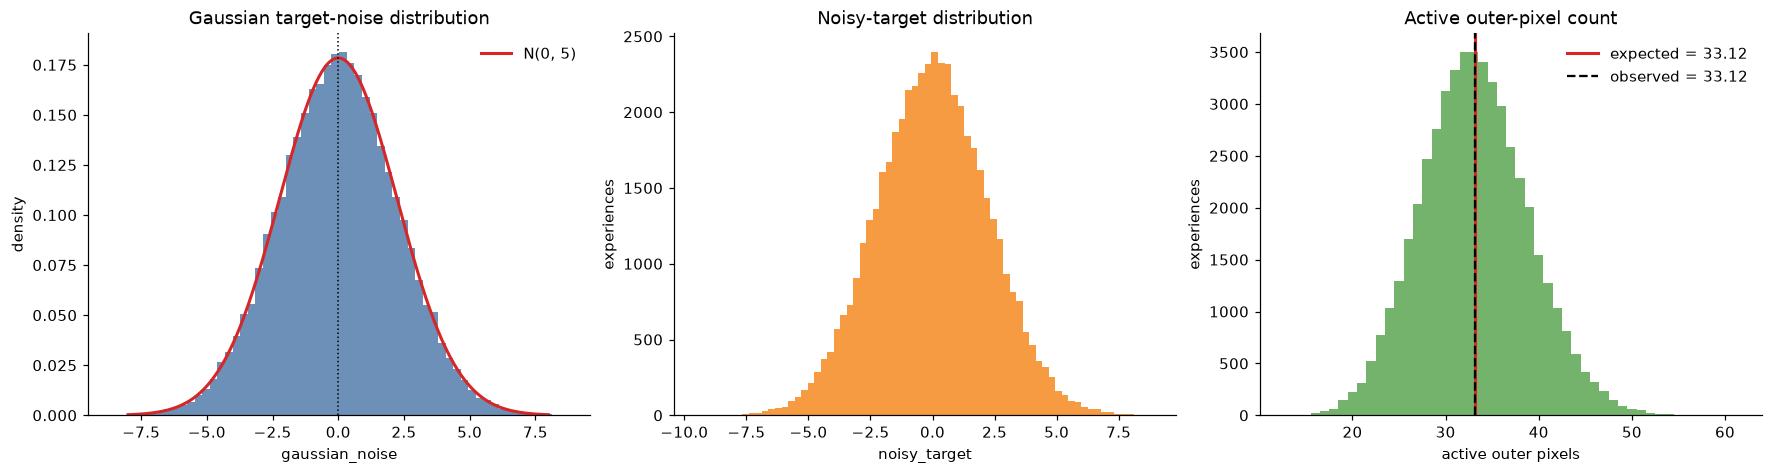

In [16]:
figure, axes = plt.subplots(1, 3, figsize=(16, 4.2), constrained_layout=True)

axes[0].hist(
    diagnostic_results.gaussian_noise,
    bins=60,
    density=True,
    color="#4C78A8",
    alpha=0.82,
)
noise_grid = np.linspace(-8.0, 8.0, 500)
gaussian_density = (
    np.exp(-0.5 * (noise_grid / expected_noise_std) ** 2)
    / (expected_noise_std * math.sqrt(2.0 * math.pi))
)
axes[0].plot(noise_grid, gaussian_density, color="#D62728", lw=2, label="N(0, 5)")
axes[0].axvline(0.0, color="black", lw=1, ls=":")
axes[0].set(
    title="Gaussian target-noise distribution",
    xlabel="gaussian_noise",
    ylabel="density",
)
axes[0].legend(frameon=False)

axes[1].hist(
    diagnostic_results.noisy_targets,
    bins=70,
    color="#F58518",
    alpha=0.82,
)
axes[1].set(
    title="Noisy-target distribution",
    xlabel="noisy_target",
    ylabel="experiences",
)

axes[2].hist(
    diagnostic_results.active_outer_counts,
    bins=np.arange(
        diagnostic_results.active_outer_counts.min() - 0.5,
        diagnostic_results.active_outer_counts.max() + 1.5,
    ),
    color="#54A24B",
    alpha=0.82,
)
axes[2].axvline(
    expected_outer_count_mean,
    color="#D62728",
    lw=2,
    label=f"expected = {expected_outer_count_mean:.2f}",
)
axes[2].axvline(
    observed_outer_count_mean,
    color="black",
    lw=1.5,
    ls="--",
    label=f"observed = {observed_outer_count_mean:.2f}",
)
axes[2].set(
    title="Active outer-pixel count",
    xlabel="active outer pixels",
    ylabel="experiences",
)
axes[2].legend(frameon=False)

plt.show()


## 10. Visual inspection

The first panel deliberately collects four no-digit, four odd-digit, and four even-digit
experiences rather than hoping that an unconditioned set of 12 contains every semantic
group. These are training-pool diagnostics only. Titles expose the digit label, clean
target, and realized noisy target.


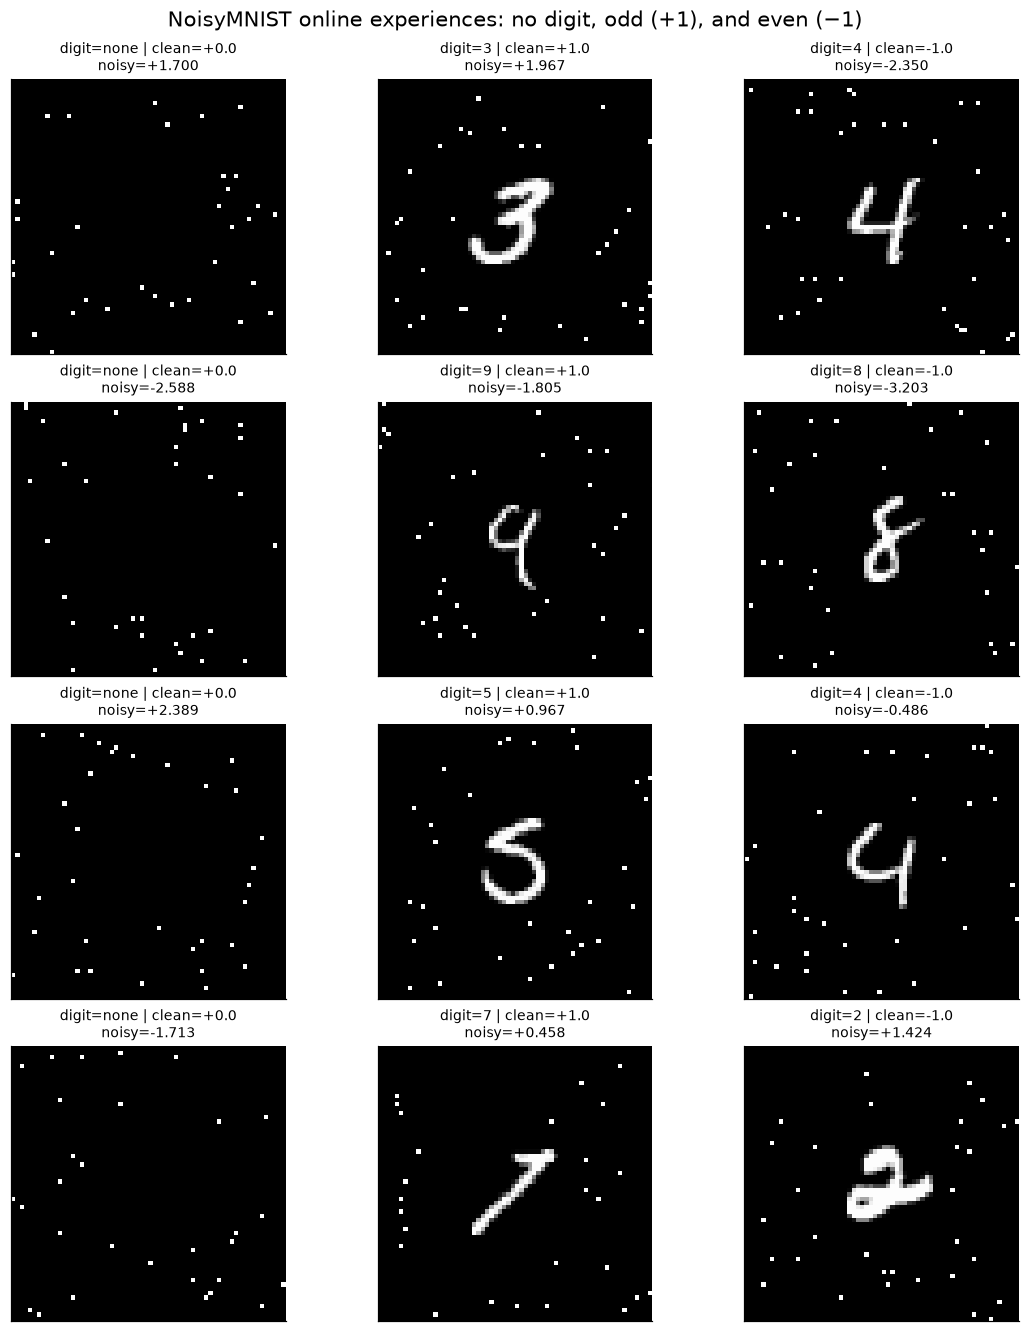

In [17]:
def collect_balanced_visual_examples(
    stream: NoisyMNISTStream,
    per_group: int = 4,
    max_attempts: int = 20_000,
) -> list[Experience]:
    """Collect equal numbers of absent, odd, and even examples for visualization."""

    groups: dict[str, list[Experience]] = {"none": [], "odd": [], "even": []}
    attempts = 0
    while any(len(group) < per_group for group in groups.values()):
        if attempts >= max_attempts:
            raise RuntimeError("Could not collect all requested visual groups.")
        experience = next(stream)
        if not experience["digit_present"]:
            group_name = "none"
        elif experience["digit_label"] % 2 == 1:
            group_name = "odd"
        else:
            group_name = "even"

        if len(groups[group_name]) < per_group:
            groups[group_name].append(experience)
        attempts += 1

    # Interleave groups so each row exposes the three target semantics.
    return [
        groups[group_name][item]
        for item in range(per_group)
        for group_name in ("none", "odd", "even")
    ]


visualization_stream = NoisyMNISTStream(
    training_pool, config, config.visualization_stream_seed
)
visual_examples = collect_balanced_visual_examples(visualization_stream, per_group=4)
assert len(visual_examples) == 12

figure, axes = plt.subplots(4, 3, figsize=(10, 12), constrained_layout=True)
for axis, experience in zip(axes.flat, visual_examples, strict=True):
    axis.imshow(
        experience["x"].detach().cpu().squeeze(0),
        cmap="gray",
        vmin=0.0,
        vmax=1.0,
        interpolation="nearest",
    )
    label_text = (
        str(experience["digit_label"])
        if experience["digit_present"]
        else "none"
    )
    axis.set_title(
        f"digit={label_text} | clean={float(experience['clean_target'].cpu()):+.1f}\n"
        f"noisy={float(experience['noisy_target'].cpu()):+.3f}",
        fontsize=9,
    )
    axis.set_xticks([])
    axis.set_yticks([])

figure.suptitle(
    "NoisyMNIST online experiences: no digit, odd (+1), and even (−1)",
    fontsize=14,
)
plt.show()


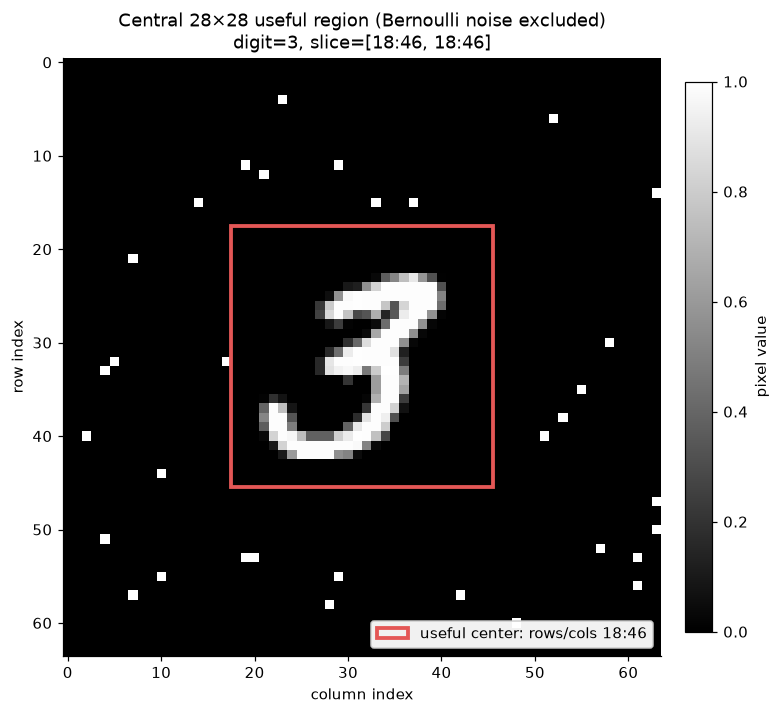

In [18]:
marked_example = next(
    experience for experience in visual_examples if experience["digit_present"]
)
figure, axis = plt.subplots(figsize=(7, 7), constrained_layout=True)
image_artist = axis.imshow(
    marked_example["x"].detach().cpu().squeeze(0),
    cmap="gray",
    vmin=0.0,
    vmax=1.0,
    interpolation="nearest",
)
center_boundary = Rectangle(
    (config.center_start - 0.5, config.center_start - 0.5),
    config.digit_size,
    config.digit_size,
    fill=False,
    edgecolor="#E45756",
    linewidth=2.5,
    label="useful center: rows/cols 18:46",
)
axis.add_patch(center_boundary)
axis.set(
    title=(
        "Central 28×28 useful region (Bernoulli noise excluded)\n"
        f"digit={marked_example['digit_label']}, slice=[18:46, 18:46]"
    ),
    xlabel="column index",
    ylabel="row index",
    xlim=(-0.5, 63.5),
    ylim=(63.5, -0.5),
)
axis.legend(loc="lower right", framealpha=0.95)
figure.colorbar(image_artist, ax=axis, fraction=0.046, pad=0.04, label="pixel value")
plt.show()


## 11. Deterministic-stream tests

make_fixed_stream constructs a fresh finite iterator from a pool, step count, and seed.
Reconstructing it yields the same ordered images, metadata, and target-noise realizations.
It does not consume a canonical stream. This is the basis for later optimizer-neutral
validation and test evaluation.


In [19]:
def make_fixed_stream(
    pool: MNISTPool,
    num_steps: int,
    seed: int,
    config: ExperimentConfig = config,
) -> Iterator[Experience]:
    """Yield a reproducible finite sequence without advancing another stream."""

    if num_steps < 0:
        raise ValueError("num_steps must be non-negative.")
    finite_stream = NoisyMNISTStream(pool, config, seed)
    for _ in range(num_steps):
        yield next(finite_stream)


def experiences_equal(left: Experience, right: Experience) -> bool:
    """Compare every tensor and metadata field bit-for-bit."""

    tensor_keys = (
        "x",
        "x_flat",
        "noisy_target",
        "clean_target",
        "gaussian_noise",
    )
    metadata_keys = (
        "digit_present",
        "digit_label",
        "mnist_index",
        "source_partition",
        "stream_step",
    )
    return all(torch.equal(left[key], right[key]) for key in tensor_keys) and all(
        left[key] == right[key] for key in metadata_keys
    )


def sequences_equal(
    left: Sequence[Experience], right: Sequence[Experience]
) -> bool:
    """Compare two finite experience sequences exactly."""

    return len(left) == len(right) and all(
        experiences_equal(a, b) for a, b in zip(left, right, strict=True)
    )


def numpy_states_equal(left: tuple[Any, ...], right: tuple[Any, ...]) -> bool:
    """Compare legacy NumPy global RNG states."""

    return (
        left[0] == right[0]
        and np.array_equal(left[1], right[1])
        and left[2:] == right[2:]
    )


In [20]:
fixed_validation_a = list(
    make_fixed_stream(validation_pool, 32, config.validation_stream_seed)
)
fixed_validation_b = list(
    make_fixed_stream(validation_pool, 32, config.validation_stream_seed)
)
same_seed_fixed_pass = sequences_equal(fixed_validation_a, fixed_validation_b)

fixed_validation_different = list(
    make_fixed_stream(validation_pool, 32, config.validation_stream_seed + 1)
)
different_seed_pass = not sequences_equal(
    fixed_validation_a, fixed_validation_different
)

reset_probe = NoisyMNISTStream(training_pool, config, config.train_stream_seed)
constructor_sequence_a = [next(reset_probe) for _ in range(16)]
reset_probe.reset()
constructor_sequence_b = [next(reset_probe) for _ in range(16)]
argument_free_reset_pass = sequences_equal(
    constructor_sequence_a, constructor_sequence_b
)

alternate_seed = config.train_stream_seed + 99
reset_probe.reset(seed=alternate_seed)
alternate_sequence_a = [next(reset_probe) for _ in range(16)]
reset_probe.reset(seed=alternate_seed)
alternate_sequence_b = [next(reset_probe) for _ in range(16)]
explicit_seed_reset_pass = sequences_equal(
    alternate_sequence_a, alternate_sequence_b
)
reset_probe.reset()
restored_constructor_sequence = [next(reset_probe) for _ in range(16)]
constructor_seed_restored_pass = sequences_equal(
    constructor_sequence_a, restored_constructor_sequence
)

python_state_before = random.getstate()
numpy_state_before = np.random.get_state()
torch_state_before = torch.get_rng_state().clone()
cuda_states_before = (
    [state.clone() for state in torch.cuda.get_rng_state_all()]
    if torch.cuda.is_available()
    else []
)
private_rng_probe = NoisyMNISTStream(
    training_pool, config, config.diagnostic_stream_seed + 2
)
_ = [next(private_rng_probe) for _ in range(8)]
cuda_states_after = (
    torch.cuda.get_rng_state_all() if torch.cuda.is_available() else []
)
global_rng_isolation_pass = bool(
    python_state_before == random.getstate()
    and numpy_states_equal(numpy_state_before, np.random.get_state())
    and torch.equal(torch_state_before, torch.get_rng_state())
    and len(cuda_states_before) == len(cuda_states_after)
    and all(
        torch.equal(before, after)
        for before, after in zip(cuda_states_before, cuda_states_after, strict=True)
    )
)

canonical_step_before = training_stream.stream_step
_ = list(make_fixed_stream(training_pool, 8, config.train_stream_seed))
fixed_stream_noninterference_pass = training_stream.stream_step == canonical_step_before

distinct_role_seeds_pass = (
    len(
        {
            config.train_stream_seed,
            config.validation_stream_seed,
            config.test_stream_seed,
        }
    )
    == 3
)

deterministic_stream_pass = all(
    [
        same_seed_fixed_pass,
        different_seed_pass,
        argument_free_reset_pass,
        explicit_seed_reset_pass,
        constructor_seed_restored_pass,
        global_rng_isolation_pass,
        fixed_stream_noninterference_pass,
        distinct_role_seeds_pass,
    ]
)

deterministic_test_table = pd.Series(
    {
        "same-seed fixed validation streams": same_seed_fixed_pass,
        "different seed changes sequence": different_seed_pass,
        "reset() restores constructor sequence": argument_free_reset_pass,
        "reset(seed=s) is reproducible": explicit_seed_reset_pass,
        "later reset() restores constructor seed": constructor_seed_restored_pass,
        "private stream leaves global RNG states unchanged": global_rng_isolation_pass,
        "fixed stream does not advance canonical stream": fixed_stream_noninterference_pass,
        "train/validation/test seeds are distinct": distinct_role_seeds_pass,
    },
    name="passed",
)
display(deterministic_test_table.to_frame())

assert deterministic_stream_pass
assert training_stream.stream_step == 0
assert validation_stream.stream_step == 0
assert test_stream.stream_step == 0
print("All deterministic-stream tests passed; no test experiences were drawn.")


,passed
same-seed fixed validation streams,True
different seed changes sequence,True
reset() restores constructor sequence,True
reset(seed=s) is reproducible,True
later reset() restores constructor seed,True
private stream leaves global RNG states unchanged,True
fixed stream does not advance canonical stream,True
train/validation/test seeds are distinct,True


All deterministic-stream tests passed; no test experiences were drawn.


## 12. Future experimental protocol

### Faithful Reproduction vs Our Extensions

**Paper-defined**

- NoisyMNIST construction
- 64 × 64 canvas
- 28 × 28 centered MNIST digit
- 10% digit probability
- 1% Bernoulli outer features
- odd/even/no-digit clean targets
- Gaussian target-noise variance 5

**Our protocol additions**

- deterministic stratified train/validation split
- fixed, role-specific seeds
- deterministic finite evaluation streams
- explicit leakage checks
- multiple-seed evaluation later

The second list strengthens reproducibility but was not specified in the Sutton/Javed note.


### Fair paired optimizer comparison

For each future experimental seed, SGD and NetworkIDBD must start from:

- identical initial neural-network weights;
- the exact same ordered training experiences;
- the exact same Gaussian target-noise realizations.

Separate streams will be reconstructed/reset to the same training seed for each optimizer.
This paired design reduces optimizer-comparison variance. Reproducing an ordered stochastic
stream for scientific comparison is **not** replay-buffer learning: each learner still
consumes each experience online, once, in order, without sampling stored past transitions.


### Future paper architecture — specification only

4096 → Linear(4096, 10000) → ReLU → Linear(10000, 1)

Paper initialization:

- input-to-hidden weights sampled uniformly from (−0.0001, 0.0001);
- hidden-to-output weights initialized to zero;
- learned input connections are visualized when their magnitude exceeds 0.0002.

Bias handling is not specified in the short note. This notebook makes no silent choice and
creates no model.


### Training-protocol warning

The faithful core experiment should not initially add early stopping, learning-rate
scheduling, large mini-batches, replay buffers, dropout, data augmentation, or weight decay.
Those changes modify the online batch-size-one credit-assignment setting and would confound
the comparison between SGD and NetworkIDBD. They may later be tested only as explicitly
labeled ablations.

Validation will later be used for hyperparameter selection only—not for weight updates and
not to terminate the paper-faithful run early unless a separate, explicitly non-faithful
experiment is defined. The official test stream remains untouched until final evaluation.


## 13. Summary

Phase 1 has established isolated MNIST pools, an exact online NoisyMNIST generator,
deterministic finite evaluation streams, structural/semantic assertions, statistical
validation, and visual diagnostics. The computed checklist below fails loudly if any
required invariant or stochastic acceptance criterion is not satisfied.

No neural network, optimizer, training loop, or NetworkIDBD equation is implemented here.


In [21]:
checklist = [
    ("MNIST partitions isolated", bool(partitions_isolated)),
    ("digit rate approximately 10%", bool(digit_rate_pass)),
    ("outer Bernoulli rate approximately 1%", bool(outer_rate_pass)),
    ("Gaussian noise mean approximately 0", bool(noise_mean_pass)),
    ("Gaussian noise variance approximately 5", bool(noise_variance_pass)),
    ("target semantics correct", bool(target_semantics_pass)),
    ("deterministic stream reproducibility correct", bool(deterministic_stream_pass)),
    (
        "center region uncontaminated by Bernoulli noise",
        bool(center_uncontaminated_pass),
    ),
]

for check_name, passed in checklist:
    print(f"- [{'PASS' if passed else 'FAIL'}] {check_name}")

assert all(passed for _, passed in checklist)
print("\nPhase 1 dataset/protocol checks complete. No model training was performed.")


- [PASS] MNIST partitions isolated
- [PASS] digit rate approximately 10%
- [PASS] outer Bernoulli rate approximately 1%
- [PASS] Gaussian noise mean approximately 0
- [PASS] Gaussian noise variance approximately 5
- [PASS] target semantics correct
- [PASS] deterministic stream reproducibility correct
- [PASS] center region uncontaminated by Bernoulli noise

Phase 1 dataset/protocol checks complete. No model training was performed.
